In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np


In [2]:
# Latex rendering
plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
plt.rc('text', usetex=True)
plt.rc('font', weight='bold')

In [3]:
#============================ Plot Setting  ================================

# --- Cosmology palette (normalized RGB) ---
COSMO_COLORS = {
    "deep_blue": (30/255, 60/255, 120/255),
    "warm_gold": (200/255, 140/255, 0/255),
    "dark_teal": (0/255, 110/255, 110/255),
    "soft_crimson": (150/255, 40/255, 40/255),
    "cool_gray": (120/255, 120/255, 120/255),
    }

sns.set_theme(
    style="ticks",
    context='talk',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["deep_blue"],
    "black",
    COSMO_COLORS["warm_gold"],
    COSMO_COLORS["cool_gray"],
    COSMO_COLORS["dark_teal"],
    COSMO_COLORS["soft_crimson"],
    ])

#General Settings
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=18)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=16)    # fontsize of the tick labels
plt.rc('ytick', labelsize=16)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=18)          # controls default text sizes



In [4]:
#====================== Files and Data ===========================

# Leer archivo (ajusta el nombre del archivo)
source=Path("/home/nicolas/Documents/Research/PhD/JWST-Data/Medium_Resolution")
plots_folder=source / "Output_data/"

df = pd.read_csv("/home/nicolas/Documents/Research/PhD/JWST-Data/Medium_Resolution/Output_data/Line_fluxes_combined_v4.tsv", sep='\t')
#df = pd.read_csv('C:\\Users\\nicol\\Documents\\Research\\PhD\\PhD-Project-Repo\\JWST-Data\\Medium_Resolution\\Output_data\\Line_fluxes_combined.tsv', sep='\t')


# Pipeline Comparion

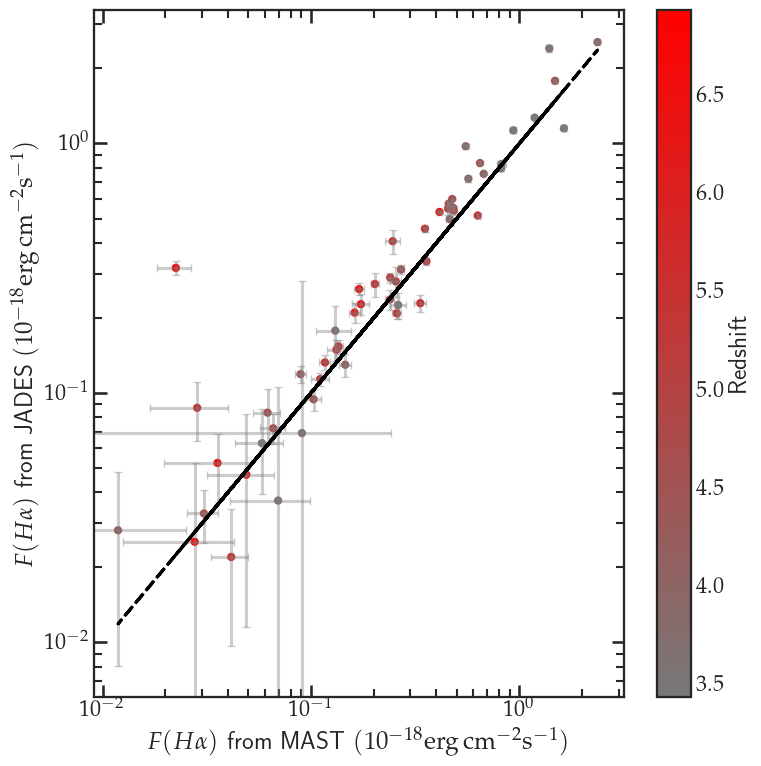

In [5]:
#------------------ H alfa ---------------------
df = df.dropna(subset=[df.columns[0],
                        df.columns[1],
                        df.columns[2],
                        df.columns[3],
                        df.columns[4],
                        df.columns[5] ])


#Guardar columnas en arrays
ID_array = df.iloc[:,0].to_numpy()
z_array  = df.iloc[:,1].to_numpy()

#Halpha data
mast_line = df.iloc[:,2].to_numpy()
mast_line_err = df.iloc[:,3].to_numpy()
jades_line = df.iloc[:,4].to_numpy()
jades_line_err = df.iloc[:,5].to_numpy()


# Definir variables para la gráfica
plt.figure(figsize=(8, 8))

from matplotlib.colors import LinearSegmentedColormap

# Custom colormap: gray → red
gray_red_cmap = LinearSegmentedColormap.from_list(
    'gray_red',
    [COSMO_COLORS['cool_gray'], 'red']
    #['lightgray', 'red']
)


plt.scatter(
    mast_line, jades_line,
    s=20,  # Tamaño de los puntos
    c=z_array,
    alpha=1,
    cmap=gray_red_cmap,
     
)

plt.errorbar(
    mast_line, jades_line,
    xerr=mast_line_err,
    yerr=jades_line_err,
    fmt='none',
    alpha=0.4,
    c='gray',
    capsize=3,
    markersize=1,
    
)

#plt.title(r"Comparison of flux estimates for $H\alpha$", color=COSMO_COLORS['soft_crimson'])
plt.plot(mast_line, mast_line, color='black', linestyle='--')
plt.xlabel(r"$F(H\alpha)$ from MAST $(10^{-18}\mathrm{erg \, cm^{-2} s^{-1})}$")
plt.ylabel(r"$F(H\alpha)$ from JADES $(10^{-18}\mathrm{erg \, cm^{-2} s^{-1})}$")
# Add colorbar
cbar = plt.colorbar()
cbar.set_label('Redshift')

plt.xscale('log')
plt.yscale('log')

plt.grid(False)
plt.minorticks_on()
plt.tight_layout()
#plt.savefig('Output_data/Flux_Comparison_Ha.pdf')
plt.show()
plt.close()


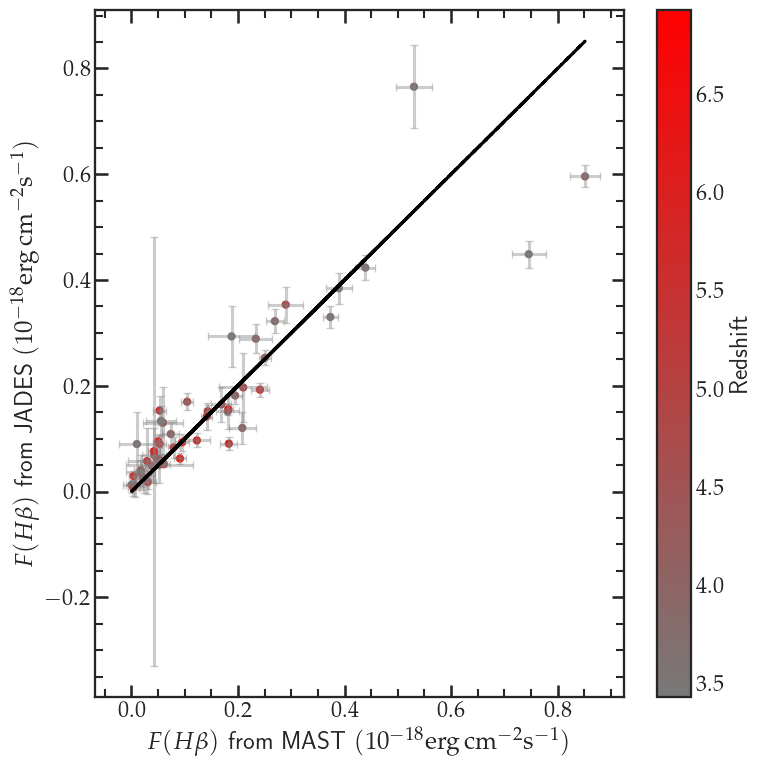

In [ ]:
#------------------ H beta ---------------------
df = df.dropna(subset=[df.columns[0],
                        df.columns[1],
                        df.columns[6],
                        df.columns[7],
                        df.columns[8],
                        df.columns[9] ])


#Guardar columnas en arrays
ID_array = df.iloc[:,0].to_numpy()
z_array  = df.iloc[:,1].to_numpy()

#Halpha data
mast_line = df.iloc[:,6].to_numpy()
mast_line_err = df.iloc[:,7].to_numpy()
jades_line = df.iloc[:,8].to_numpy()
jades_line_err = df.iloc[:,9].to_numpy()

plt.figure(figsize=(8, 8))
plt.scatter(
    mast_line, jades_line,
    s=20,  # Tamaño de los puntos
    c=z_array,
    alpha=1,
    cmap=gray_red_cmap,
     
)

plt.errorbar(
    mast_line, jades_line,
    xerr=mast_line_err,
    yerr=jades_line_err,
    fmt='none',
    alpha=0.4,
    c='gray',
    capsize=3,
    markersize=1,
    
)


plt.plot(mast_line, mast_line, color='black', linestyle='--')
plt.xlabel(r"$F(H\beta)$ from MAST $(10^{-18}\mathrm{erg \, cm^{-2} s^{-1})}$")
plt.ylabel(r"$F(H\beta)$ from JADES $(10^{-18}\mathrm{erg \, cm^{-2} s^{-1})}$")
# Add colorbar
cbar = plt.colorbar()
cbar.set_label('Redshift')


plt.xscale('log')
plt.yscale('log')


plt.grid(False)
plt.minorticks_on()
plt.tight_layout()
#plt.savefig('Output_data/Flux_Comparison_Hb.pdf')
plt.show()
plt.close()

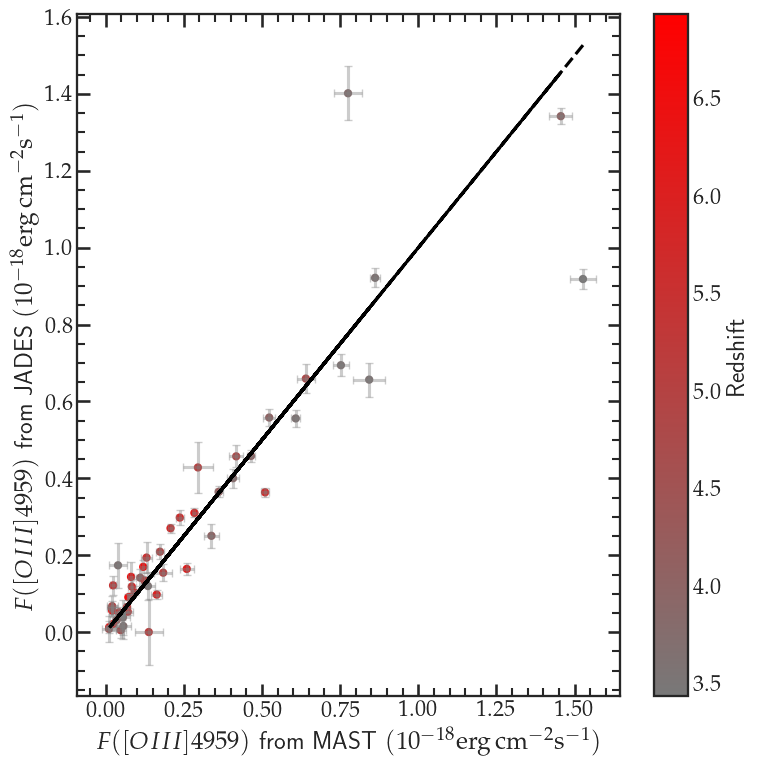

In [ ]:
#------------------ [OIII]4959 ---------------------
df = df.dropna(subset=[df.columns[0],
                        df.columns[1],
                        df.columns[10],
                        df.columns[11],
                        df.columns[12],
                        df.columns[13]])


#Guardar columnas en arrays
ID_array = df.iloc[:,0].to_numpy()
z_array  = df.iloc[:,1].to_numpy()

#Halpha data
mast_line = df.iloc[:,10].to_numpy()
mast_line_err = df.iloc[:,11].to_numpy()
jades_line = df.iloc[:,12].to_numpy()
jades_line_err = df.iloc[:,13].to_numpy()


plt.figure(figsize=(8, 8))
plt.scatter(
    mast_line, jades_line,
    s=20,  # Tamaño de los puntos
    c=z_array,
    alpha=1,
    cmap=gray_red_cmap,
     
)

plt.errorbar(
    mast_line, jades_line,
    xerr=mast_line_err,
    yerr=jades_line_err,
    fmt='none',
    alpha=0.4,
    c='gray',
    capsize=3,
    markersize=1,
    
)


plt.plot(mast_line, mast_line, color='black', linestyle='--')
plt.xlabel(r"$F([OIII]4959)$ from MAST $(10^{-18}\mathrm{erg \, cm^{-2} s^{-1})}$")
plt.ylabel(r"$F([OIII]4959)$ from JADES $(10^{-18}\mathrm{erg \, cm^{-2} s^{-1})}$")
# Add colorbar
cbar = plt.colorbar()
cbar.set_label('Redshift')


plt.xscale('log')
plt.yscale('log')


plt.grid(False)
plt.minorticks_on()
plt.tight_layout()
#plt.savefig('Output_data/Flux_Comparison_O3.pdf')
plt.show()
plt.close()

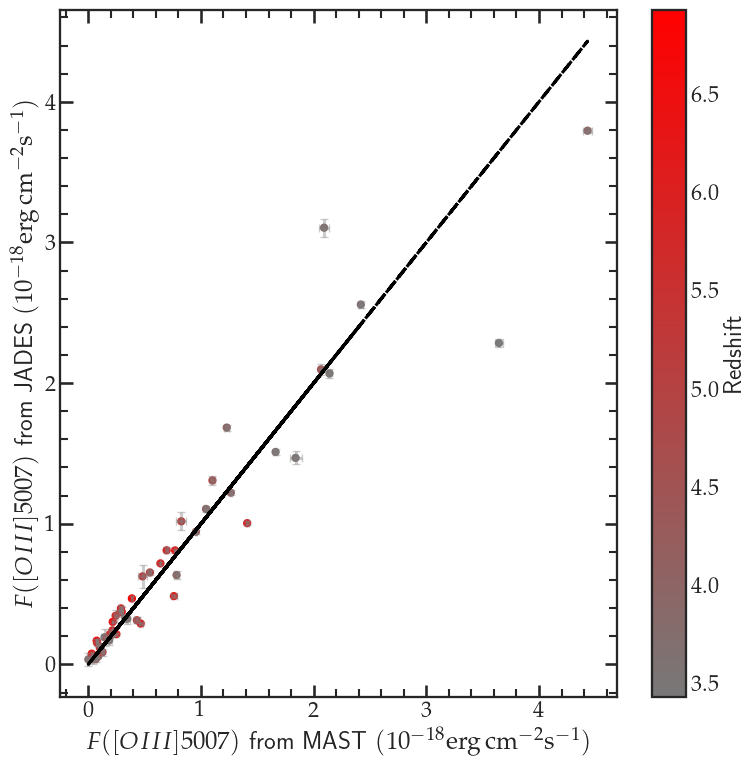

In [ ]:
#------------------ [OIII]5007 ---------------------
df = df.dropna(subset=[df.columns[0],
                        df.columns[1],
                        df.columns[14],
                        df.columns[15],
                        df.columns[16],
                        df.columns[17]])


#Guardar columnas en arrays
ID_array = df.iloc[:,0].to_numpy()
z_array  = df.iloc[:,1].to_numpy()

#Halpha data
mast_line = df.iloc[:,14].to_numpy()
mast_line_err = df.iloc[:,15].to_numpy()
jades_line = df.iloc[:,16].to_numpy()
jades_line_err = df.iloc[:,17].to_numpy()

plt.figure(figsize=(8, 8))
plt.scatter(
    mast_line, jades_line,
    s=20,  # Tamaño de los puntos
    c=z_array,
    alpha=1,
    cmap=gray_red_cmap,
     
)

plt.errorbar(
    mast_line, jades_line,
    xerr=mast_line_err,
    yerr=jades_line_err,
    fmt='none',
    alpha=0.4,
    c='gray',
    capsize=3,
    markersize=1,
    
)


plt.plot(mast_line, mast_line, color='black', linestyle='--')
plt.xlabel(r"$F([OIII]5007)$ from MAST $(10^{-18}\mathrm{erg \, cm^{-2} s^{-1})}$")
plt.ylabel(r"$F([OIII]5007)$ from JADES $(10^{-18}\mathrm{erg \, cm^{-2} s^{-1})}$")
# Add colorbar
cbar = plt.colorbar()
cbar.set_label('Redshift')


plt.xscale('log')
plt.yscale('log')


plt.grid(False)
plt.minorticks_on()
plt.tight_layout()
#plt.savefig('Output_data/Flux_Comparison_O3.pdf')
plt.show()
plt.close()

In [16]:
# Create a new dataframe with ID and comparison columns for each emission line
result_df = pd.DataFrame()
result_df['ID'] = df['ID']

# H-alpha: abs(col2 - col4) < col3 + col5
result_df['Ha_Consistent'] = np.abs(df.iloc[:, 2] - df.iloc[:, 4]) < (df.iloc[:, 3] + df.iloc[:, 5])

# H-beta: abs(col6 - col8) < col7 + col9
result_df['Hb_Consistent'] = np.abs(df.iloc[:, 6] - df.iloc[:, 8]) < (df.iloc[:, 7] + df.iloc[:, 9])

# [OIII]4959: abs(col10 - col12) < col11 + col13
result_df['OIII4959_Consistent'] = np.abs(df.iloc[:, 10] - df.iloc[:, 12]) < (df.iloc[:, 11] + df.iloc[:, 13])

# [OIII]5007: abs(col14 - col16) < col15 + col17
result_df['OIII5007_Consistent'] = np.abs(df.iloc[:, 14] - df.iloc[:, 16]) < (df.iloc[:, 15] + df.iloc[:, 17])

result_sumary = pd.DataFrame(result_df)

result_sumary

,ID,Ha_Consistent,Hb_Consistent,OIII4959_Consistent,OIII5007_Consistent
0,3184,False,False,False,False
1,3334,True,False,False,False
2,3968,True,True,True,True
3,4197,True,True,True,True
4,4270,False,False,False,False
5,4282,True,True,False,True
6,4297,False,True,False,False
7,4404,False,True,False,False
8,5329,True,True,True,True
10,5759,True,True,True,False


In [17]:
# Create a new dataframe with ID and comparison columns for each emission line
result_df = pd.DataFrame()
result_df['ID'] = df['ID']

# H-alpha: abs(col2 - col4) < col3 + col5
result_df['Ha_Consistent'] = np.abs(df.iloc[:, 2] - df.iloc[:, 4]) / np.sqrt(df.iloc[:, 3]**2 + df.iloc[:, 5]**2)

# H-beta: abs(col6 - col8) < col7 + col9
result_df['Hb_Consistent'] = np.abs(df.iloc[:, 6] - df.iloc[:, 8]) / np.sqrt(df.iloc[:, 7]**2 + df.iloc[:, 9]**2)

# [OIII]4959: abs(col10 - col12) < col11 + col13
result_df['OIII4959_Consistent'] = np.abs(df.iloc[:, 10] - df.iloc[:, 12]) / np.sqrt(df.iloc[:, 11]**2 + df.iloc[:, 13]**2)

# [OIII]5007: abs(col14 - col16) < col15 + col17
result_df['OIII5007_Consistent'] = np.abs(df.iloc[:, 14] - df.iloc[:, 16]) / np.sqrt(df.iloc[:, 15]**2 + df.iloc[:, 17]**2)

result_sumary = pd.DataFrame(result_df)

result_sumary

,ID,Ha_Consistent,Hb_Consistent,OIII4959_Consistent,OIII5007_Consistent
0,3184,11.075760,7.248112,12.769788,29.195308
1,3334,0.748770,1.895927,2.572298,7.166347
2,3968,1.299334,0.609458,0.435781,0.923159
3,4197,0.082385,0.460883,0.328969,0.691993
4,4270,3.120722,7.361568,2.706799,15.610278
5,4282,0.436269,1.167057,2.092159,0.721099
6,4297,1.968744,0.083578,1.549790,2.079255
7,4404,6.247903,0.020156,2.565932,5.007444
8,5329,1.031031,0.738880,0.363230,0.491196
10,5759,0.082238,0.022867,0.814059,3.304967


# Comparison with Catalogue

In [6]:
from astropy.io import fits
catalog_file = source / 'hlsp_jades_jwst_nirspec_goods-s_gratings-line-fluxes_v1.1_catalog.fits'
#catalog_file = source / 'jades_dr3_medium_gratings_public_gs_v1.1.fits'

with fits.open(catalog_file) as file:
    data = file[1].data

    Cat_ID = data['NIRSpec_ID']
    Cat_Hb = data['Hb_4861_flux']
    Cat_Hb_err = data['HB_4861_err']
    Cat_Ha = data['Ha_6563_flux']
    Cat_Ha_er = data['HA_6563_err']
    


In [7]:
df = pd.read_csv("/home/nicolas/Documents/Research/PhD/JWST-Data/Medium_Resolution/Output_data/Line_fluxes_combined.tsv", sep='\t')

#Guardar columnas en arrays
ID_array = df.iloc[:,0].to_numpy()
z_array  = df.iloc[:,1].to_numpy()

#Halpha data
mast_line = df.iloc[:,2].to_numpy()
mast_line_err = df.iloc[:,3].to_numpy()
jades_line = df.iloc[:,4].to_numpy()
jades_line_err = df.iloc[:,5].to_numpy()


# Create combined dataframe with only JADES Ha data
combined_df = pd.DataFrame({
    'ID': ID_array,
    'Redshift': z_array,
    'JADES_Ha_Flux': jades_line,
    'JADES_Ha_Err': jades_line_err,
})

print(f"Combined dataframe shape: {combined_df.shape}")
print(f"Column names: {list(combined_df.columns)}")
print(f"\nFirst few rows:\n{combined_df}")

Combined dataframe shape: (62, 4)
Column names: ['ID', 'Redshift', 'JADES_Ha_Flux', 'JADES_Ha_Err']

First few rows:
          ID  Redshift  JADES_Ha_Flux  JADES_Ha_Err
0       3184  3.467620       1.301493      0.017674
1       3334  6.705930       0.054530      0.004276
2       3968  5.768470       0.045446      0.006813
3       4197  3.748809       0.079966      0.015118
4       4270  4.022612       2.547358           NaN
..       ...       ...            ...           ...
57  10013905  7.197212            NaN           NaN
58  10015338  5.076272       0.491343           NaN
59  10016186  3.927926       0.722312           NaN
60  10016374  5.503256       0.280826           NaN
61  10035295  3.588924       1.292516      0.017526

[62 rows x 4 columns]


In [8]:
# Create catalog dataframe with only Ha data
Cat_ID_native = np.asarray(Cat_ID, dtype=Cat_ID.dtype.newbyteorder('='))
Cat_Ha_native = np.asarray(Cat_Ha, dtype=Cat_Ha.dtype.newbyteorder('='))
Cat_Ha_er_native = np.asarray(Cat_Ha_er, dtype=Cat_Ha_er.dtype.newbyteorder('='))

catalog_df = pd.DataFrame({
    'ID': Cat_ID_native,
    'Catalog_Ha_Flux': Cat_Ha_native,
    'Catalog_Ha_Err': Cat_Ha_er_native,
})

print(f"Catalog dataframe shape: {catalog_df.shape}")
print(f"Column names: {list(catalog_df.columns)}")
print(f"\nFirst few rows:\n{catalog_df.head()}")

Catalog dataframe shape: (2525, 3)
Column names: ['ID', 'Catalog_Ha_Flux', 'Catalog_Ha_Err']

First few rows:
    ID  Catalog_Ha_Flux  Catalog_Ha_Err
0   38              NaN             NaN
1  416              NaN             NaN
2  455              NaN             NaN
3  490              NaN             NaN
4  500              NaN             NaN


In [9]:
# Remove duplicate IDs, keeping the row with non-NaN flux values
catalog_df = catalog_df.sort_values(by=['ID', 'Catalog_Ha_Flux'], na_position='last').drop_duplicates(subset=['ID'], keep='first').reset_index(drop=True)

print(f"Deduplicated catalog dataframe shape: {catalog_df.shape}")
print(f"Column names: {list(catalog_df.columns)}")
print(f"\nFirst few rows:\n{catalog_df.head()}")

Deduplicated catalog dataframe shape: (2501, 3)
Column names: ['ID', 'Catalog_Ha_Flux', 'Catalog_Ha_Err']

First few rows:
    ID  Catalog_Ha_Flux  Catalog_Ha_Err
0   38              NaN             NaN
1  416              NaN             NaN
2  455              NaN             NaN
3  490              NaN             NaN
4  500              NaN             NaN


In [10]:
# Remove rows with NaN values in catalog_df from both dataframes, then merge
# First, identify IDs in catalog_df that have non-NaN flux values
valid_ids = catalog_df[catalog_df['Catalog_Ha_Flux'].notna()]['ID'].values

# Filter both dataframes to keep only valid IDs
combined_df = combined_df[combined_df['ID'].isin(valid_ids)].reset_index(drop=True)
catalog_df = catalog_df[catalog_df['ID'].isin(valid_ids)].reset_index(drop=True)

# Merge the two dataframes on ID
merged_df = pd.merge(combined_df, catalog_df, on='ID', how='inner')

print(f"Merged dataframe shape: {merged_df.shape}")
print(f"Column names: {list(merged_df.columns)}")
print(f"\nFirst few rows:\n{merged_df.head()}")
print(f"\nNo NaN values in merged_df: {merged_df.isna().sum().sum() == 0}")

merged_df

Merged dataframe shape: (45, 6)
Column names: ['ID', 'Redshift', 'JADES_Ha_Flux', 'JADES_Ha_Err', 'Catalog_Ha_Flux', 'Catalog_Ha_Err']

First few rows:
     ID  Redshift  JADES_Ha_Flux  JADES_Ha_Err  Catalog_Ha_Flux  \
0  3184  3.467620       1.301493      0.017674         5.679632   
1  3968  5.768470       0.045446      0.006813         0.305350   
2  4270  4.022612       2.547358           NaN        12.571805   
3  4297  6.712776       0.184973      0.014892         1.496905   
4  4404  5.763688       0.445542      0.009171         2.958331   

   Catalog_Ha_Err  
0        0.168003  
1        0.056769  
2        0.151265  
3        0.118600  
4        0.094396  

No NaN values in merged_df: False


,ID,Redshift,JADES_Ha_Flux,JADES_Ha_Err,Catalog_Ha_Flux,Catalog_Ha_Err
0,3184,3.467620,1.301493,0.017674,5.679632,0.168003
1,3968,5.768470,0.045446,0.006813,0.305350,0.056769
2,4270,4.022612,2.547358,NaN,12.571805,0.151265
3,4297,6.712776,0.184973,0.014892,1.496905,0.118600
4,4404,5.763688,0.445542,0.009171,2.958331,0.094396
5,5329,3.587301,0.247112,0.020220,1.157316,0.127473
6,5457,4.863151,NaN,NaN,0.923317,0.074624
7,5759,5.051894,0.224475,0.009735,1.455261,0.119862
8,6002,5.936858,0.142719,0.003112,1.014251,0.045718
9,6246,5.561598,0.110275,0.004242,0.749253,0.048691


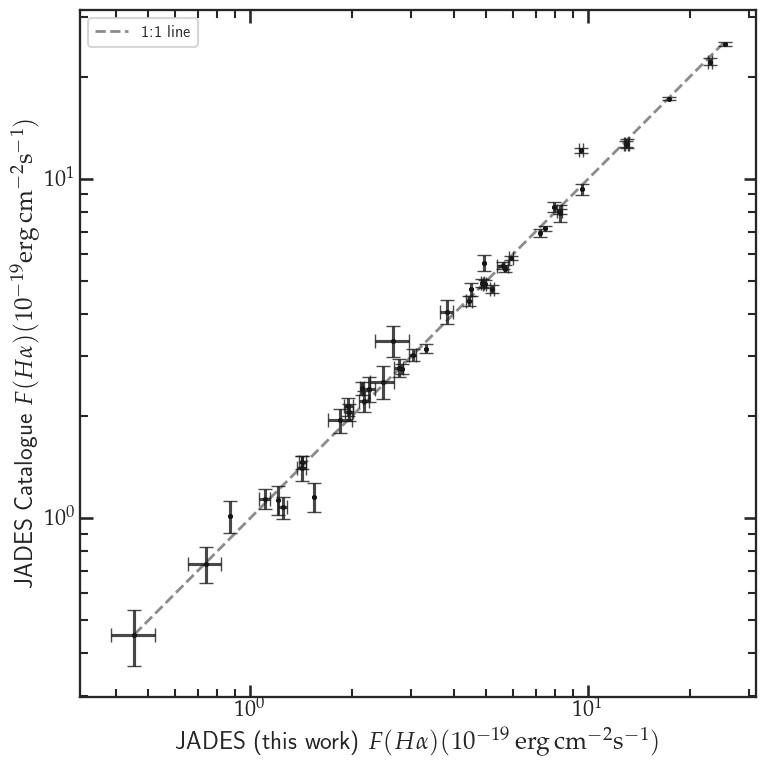

In [12]:
# Create scatter plot with error bars, color coded by redshift
fig, ax = plt.subplots(figsize=(8,8))
from matplotlib.colors import LinearSegmentedColormap

# Custom colormap: gray → red
gray_red_cmap = LinearSegmentedColormap.from_list(
    'gray_red',
    [COSMO_COLORS['cool_gray'], 'red']
    #['lightgray', 'red']
)

scale=10
# Create scatter plot with color coding by redshift
scatter = ax.scatter(
    scale*merged_df['JADES_Ha_Flux'],
    scale*merged_df['Catalog_Ha_Flux']/(1+merged_df['Redshift']),
    s=10,
    alpha=1,
    color='black',
    edgecolors='black',
    linewidth=0.5
)

# Add error bars

ax.errorbar(
    scale*merged_df['JADES_Ha_Flux'],
    scale*merged_df['Catalog_Ha_Flux']/(1+merged_df['Redshift']),
    xerr=scale*merged_df['JADES_Ha_Err'],
    yerr=scale*merged_df['Catalog_Ha_Err']/(1+merged_df['Redshift']),
    fmt='none',
    ecolor='k',
    alpha=0.8,
    capsize=5,
    markersize=3,
)

# Add diagonal reference line
flux_range = [
   scale* min(merged_df['JADES_Ha_Flux'].min(), merged_df['JADES_Ha_Flux'].min()),
    scale* max(merged_df['JADES_Ha_Flux'].max(), merged_df['JADES_Ha_Flux'].max())
]
ax.plot(flux_range,flux_range, 'k--', alpha=0.5, linewidth=2, label='1:1 line')

# Labels and title
ax.set_xlabel(r'JADES (this work) $F (H\alpha) (10^{-19} \, \mathrm{erg \, cm^{-2} s^{-1}})$')
ax.set_ylabel(r'JADES Catalogue $F (H\alpha) (10^{-19} \mathrm{erg \, cm^{-2} s^{-1})}$')
ax.minorticks_on()

ax.grid(False)

plt.xscale('log')
plt.yscale('log')


ax.legend(fontsize=12)
plt.tight_layout()
#plt.savefig(plots_folder / '_Comparison_Ha.pdf')
plt.show()

plt.close()